<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/Robbins_Monro_sequential_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# we want estimate mean value of gaussian dist. by robbins monro algorithm sequential estimation
''' robbins monro general equations theta_(n) = theta_(n-1) + a_(n-1).z(thete_(n-1))
here theta(n) = estimated parameter theta,
a_(n-1) = coefficients a_n-1 that satisfies three conditions see PRML page 96,
z(theta_(n-1)) = observed value of z when theta takes value theta_n-1

robbins monro algorithm applicable to all non gaussian probability distribution where maximum likelihood estimation is done
if we consider a general maximum likelihood solution that is  =
d/d(theta_ML){avg loglikelihood} = 0 ... see eq 2.133 in PRML
law of large number says if___ N tensed to infinite d/d(theta_ml){avg loglikelihood} is equal to expected(loglikelihood)
it goes to true mean, see eq 2.134

for gaussian distribution d/d(theta_ML){loglikehood of gaussian probability} = [1/sigma^2(x - mu_ML)]
substitute this into robbins monro algorithm...
theta_(n) = theta_(n-1) + a_(n-1).z(thete_(n-1))
mu_ML = mu_ML_(n-1) + 1/n(Xn - mu_ML_(n-1)); (Xn - mu_ML_(n-1)) = error signal

here,
mu_ML_(n-1) = initial_guess
let mu = parameter '''


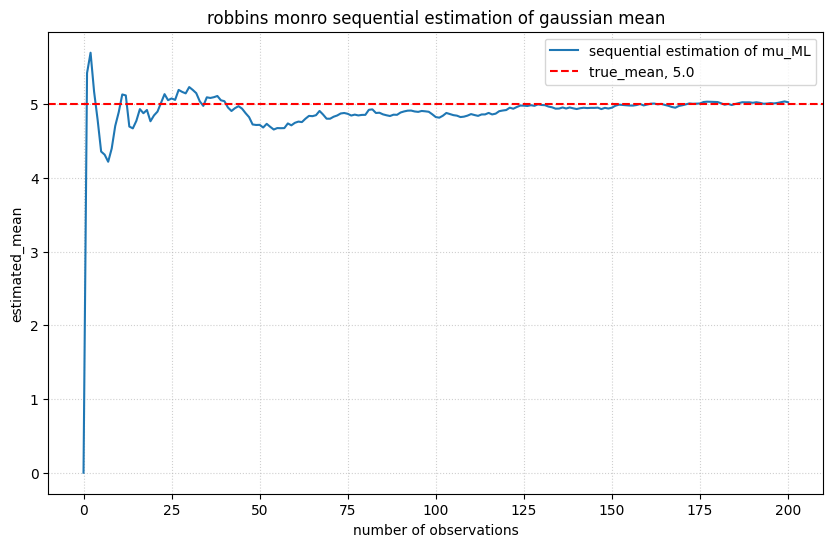

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# generate random data for gaussian dist.
true_mean, true_variance = 5.0, 2.0
observations = 200
random_data = np.random.normal(true_mean, true_variance, observations)

initial_guess = 0
current_mu = initial_guess
mu_history = [current_mu]

for index,data in enumerate(random_data,start = 1):

  a_n = 1.0/index
  error_signal = (data - current_mu)
  updated_mu = current_mu + a_n*error_signal
  mu_history.append(updated_mu.tolist())
  current_mu = updated_mu

plt.figure(figsize = (10,6))
plt.plot(range(observations + 1),mu_history, label = 'sequential estimation of mu_ML')
plt.axhline(true_mean, linestyle = '--', color = 'red', label = f"true_mean, {true_mean}")
plt.xlabel('number of observations')
plt.ylabel('estimated_mean')
plt.title('robbins monro sequential estimation of gaussian mean')
plt.grid(True, linestyle = ":",alpha = 0.6)
plt.legend()
plt.show()

